**Başlamadan önce:**

osmnx → OpenStreetMap verilerini Python’a kolayca çekmemizi sağlar.

İlleri, ilçeleri, mahalleleri adrese göre sorgulayabiliriz

**Kurulum :**
```bash
pip install osmnx
```

In [3]:
import osmnx as ox
import pandas as pd

**3. Şehir (İl) Koordinatlarını Alma**

In [6]:
city = "İstanbul, Türkiye"
gdf_city = ox.geocode_to_gdf(city)
print(gdf_city[["display_name", "geometry"]])

                       display_name  \
0  Istanbul, Marmara Region, Turkey   

                                            geometry  
0  POLYGON ((27.97085 41.09983, 27.97418 41.09898...  


**4. İlçe Koordinatları Alma**

Burada admin_level filtresi kullanılır.
- İl = admin_level=4
- İlçe = admin_level=6
- Mahalle = admin_level=10

In [8]:
districts = ox.features_from_place(
    "İstanbul, Türkiye", {"admin_level": "6"}
)
print(districts[["name", "geometry"]].head())

                                       name  \
element  id                                   
node     12740902630  Bakırköy Kaymakamlığı   
relation 963209                      Adalar   
         1211204                   Çayırova   
         1211491                    Kandıra   
         1211491                    Kandıra   

                                                               geometry  
element  id                                                              
node     12740902630                          POINT (28.82533 40.97823)  
relation 963209       MULTIPOLYGON (((29.11346 40.81813, 29.11339 40...  
         1211204      POLYGON ((29.36161 40.84912, 29.36174 40.84952...  
         1211491      MULTIPOLYGON (((29.83408 41.01638, 29.835 41.0...  
         1211491      MULTIPOLYGON (((29.83408 41.01638, 29.835 41.0...  


**6.Mahalle kordinatları alma**

In [11]:
neighborhoods = ox.features_from_place(
    "Kadıköy, İstanbul, Türkiye", {"place": ["neighbourhood", "suburb"]}
)

print(neighborhoods[["name", "geometry"]].head())


                          name                   geometry
element id                                               
node    251355458      Göztepe  POINT (29.06668 40.97872)
        821887960    Fikirtepe  POINT (29.05162 40.99322)
        1867128457     Erenköy  POINT (29.07589 40.97218)
        2437930520  Fenerbahçe  POINT (29.03755 40.96955)
        2491338600    Caferağa  POINT (29.02481 40.98504)


**6. Tekil Koordinatlar (Polygon → Nokta)**

Bazen sadece merkez nokta lazım olur:

In [12]:
neighborhoods["centroid"] = neighborhoods.centroid
print(neighborhoods[["name", "centroid"]].head())

                          name                   centroid
element id                                               
node    251355458      Göztepe  POINT (29.06668 40.97872)
        821887960    Fikirtepe  POINT (29.05162 40.99322)
        1867128457     Erenköy  POINT (29.07589 40.97218)
        2437930520  Fenerbahçe  POINT (29.03755 40.96955)
        2491338600    Caferağa  POINT (29.02481 40.98504)


C:\Users\onur\AppData\Local\Temp\ipykernel_8832\1790330303.py:1: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  neighborhoods["centroid"] = neighborhoods.centroid


**7. Haritada Görselleştirme**

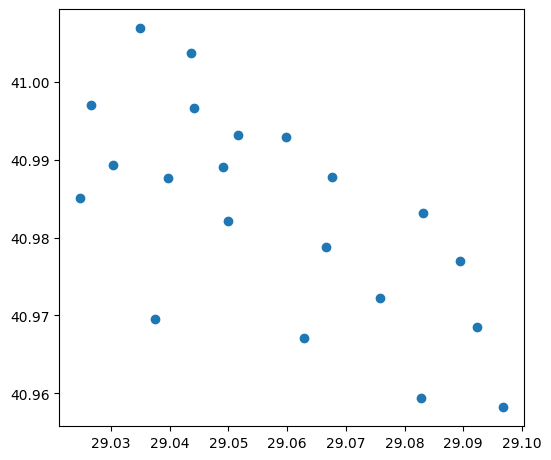

In [19]:
import matplotlib.pyplot as plt

neighborhoods.plot(figsize=(6,6))
plt.show()


In [25]:
import osmnx as ox
import pandas as pd
import time

# İstanbul ilçeleri listesi
districts_list = [
    "Adalar", "Arnavutköy", "Ataşehir", "Avcılar", "Bağcılar", "Bahçelievler",
    "Bakırköy", "Başakşehir", "Bayrampaşa", "Beşiktaş", "Beykoz", "Beylikdüzü",
    "Beyoğlu", "Büyükçekmece", "Çatalca", "Çekmeköy", "Esenler", "Esenyurt",
    "Eyüpsultan", "Fatih", "Gaziosmanpaşa", "Güngören", "Kadıköy", "Kağıthane",
    "Kartal", "Küçükçekmece", "Maltepe", "Pendik", "Sancaktepe", "Sarıyer",
    "Silivri", "Şile", "Şişli", "Sultanbeyli", "Sultangazi", "Tuzla", "Ümraniye",
    "Üsküdar", "Zeytinburnu"
]

# Örnek mahalleler (tüm mahalleleri almak istersen OSM verisi veya CSV kullan)
mahalle_dict = {
    "Kadıköy": ["Caferağa", "Rasimpaşa", "Fenerbahçe", "Erenköy"],
    "Beşiktaş": ["Levent", "Etiler", "Ortaköy", "Arnavutköy"]
}

all_data = []

for district in districts_list:
    neighborhoods = mahalle_dict.get(district, [])
    
    for nbh in neighborhoods:
        try:
            gdf = ox.geocode_to_gdf(f"{nbh}, {district}, İstanbul, Türkiye")
            centroid = gdf.geometry.iloc[0].centroid
            all_data.append({
                "İl": "İstanbul",
                "İlçe": district,
                "Mahalle": nbh,
                "Lat": centroid.y,
                "Lon": centroid.x
            })
            time.sleep(1)
        except Exception as e:
            print(f"{district} - {nbh} alınamadı:", e)

# DataFrame oluştur
df = pd.DataFrame(all_data)

# Görünümü temizle
pd.set_option("display.max_rows", 20)
pd.set_option("display.width", 100)

print(df.head())
df.to_csv("istanbul_mahalleler_latlon.csv", index=False)


         İl      İlçe     Mahalle        Lat        Lon
0  İstanbul  Beşiktaş      Levent  41.081565  29.016902
1  İstanbul  Beşiktaş      Etiler  41.084418  29.036086
2  İstanbul  Beşiktaş     Ortaköy  41.054594  29.027702
3  İstanbul  Beşiktaş  Arnavutköy  41.068223  29.041266
4  İstanbul   Kadıköy    Caferağa  40.985092  29.024812
